In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# helper functions to load and prepare data
def load_data(filepath):
    """
    Loads a CSV dataset from scratch.
    The last column is assumed to be the target 'y'.
    All preceding columns are features 'X'.
    """
    # Load the full dataset from the file
    data = np.genfromtxt(filepath, delimiter=',')
    
    # Separate features (all columns except the last)
    X = data[:, :-1]
    
    # Separate target (the last column) and reshape to a column vector
    y = data[:, -1].reshape(-1, 1)
    
    return X, y

def add_bias_term(X):
    """
    Adds a column of ones to the beginning of the feature matrix X
    to account for the bias (intercept) term.
    """
    # Create a column vector of ones with N rows
    N = X.shape[0]
    bias_column = np.ones((N, 1))
    
    # Stack the bias column and the original features horizontally
    return np.hstack((bias_column, X))

def mean_squared_error(X, y, w):
    """
    Calculates the Mean Squared Error (MSE) loss.
    """
    N = X.shape[0]
    predictions = X @ w
    error = predictions - y
    
    # MSE = (1/N) * sum(error^2)
    mse = (1 / N) * np.sum(error**2)
    return mse



In [8]:
# --- Load and Prepare Data ---

# Load data from the provided files
X_train, y_train = load_data('A2Q2Data_train - A2Q2Data_train.csv')
X_test, y_test = load_data('A2Q2Data_test - A2Q2Data_test.csv')

# Add bias terms to our feature matrices

# X_train_b will have shape (10000, 101)
# X_test_b will have shape (N_test, 101)
X_train_b = add_bias_term(X_train)
X_test_b = add_bias_term(X_test)

print(f"Training data X shape: {X_train_b.shape}")
print(f"Training data y shape: {y_train.shape}")
print(f"Test data X shape: {X_test_b.shape}")
print(f"Test data y shape: {y_test.shape}")

Training data X shape: (10000, 101)
Training data y shape: (10000, 1)
Test data X shape: (500, 101)
Test data y shape: (500, 1)


In [9]:
# part 1: Analytical Solution

def get_analytical_solution(X, y):
    """
    Calculates the analytical least squares solution using the Normal Equation.
    w = (X^T * X)^-1 * (X^T * y)
    """
    try:
        # Calculate X^T * X
        XTX = X.T @ X
        
        # Calculate X^T * y
        XTy = X.T @ y
        
        # Calculate (X^T * X)^-1
        XTX_inv = np.linalg.inv(XTX)
        
        # Calculate w
        w = XTX_inv @ XTy
        
        return w
        
    except np.linalg.LinAlgError:
        print("Error: The matrix X^T*X is singular and cannot be inverted.")
        # Can use the pseudo-inverse (np.linalg.pinv) as a fallback | NOT NEEDED
        # w = np.linalg.pinv(XTX) @ XTy
        return None

print("\n--- Part (i): Analytical Solution ---")
w_ml = get_analytical_solution(X_train_b, y_train)

if w_ml is not None:
    print(f"Shape of w_ml: {w_ml.shape}")
    print("w_ml (first 5 components):")
    print(w_ml[:5])


--- Part (i): Analytical Solution ---
Shape of w_ml: (101, 1)
w_ml (first 5 components):
[[ 0.01922968]
 [-0.00822857]
 [-0.01407351]
 [-0.00402943]
 [ 0.0023122 ]]


Text(0, 0.5, 'Weight Value')

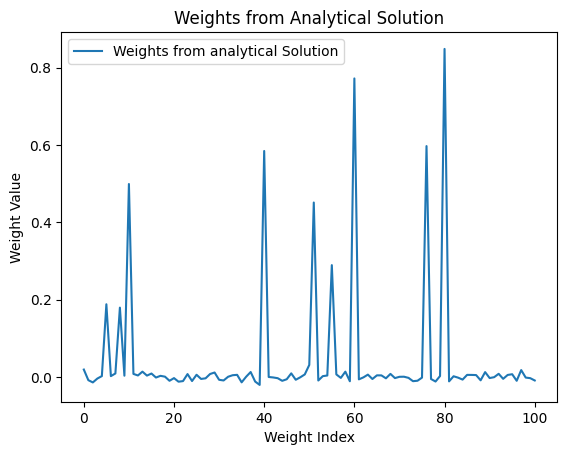

In [10]:
# intuitive visualization of weights from analytical solution
plt.plot(w_ml, label = 'Weights from analytical Solution')
plt.title("Weights from Analytical Solution")
plt.legend()
plt.xlabel("Weight Index")
plt.ylabel("Weight Value")

In [11]:
# Test MSE on training and test sets
train_mse = mean_squared_error(X_train_b, y_train, w_ml)
test_mse = mean_squared_error(X_test_b, y_test, w_ml)
print(f"Training MSE (Analytical): {train_mse}")
print(f"Test MSE (Analytical): {test_mse}")

Training MSE (Analytical): 0.03968521086820023
Test MSE (Analytical): 0.37075150228804377


In [12]:
# helper function for gradient descent
def gradient_descent(X, y, w_ml_target, learning_rate = 0.01, n_iterations= 2000):
    """
    Performs batch gradient descent.
    
    Returns:
    - w: The final weight vector.
    - norm_differences: A list of ||w_t - w_ml|| norms at each iteration.
    """
    N, D = X.shape
    
    # 1. Initialize w at zeros
    w = np.zeros((D, 1))
    
    norm_differences = []
    
    # 2. Iterate for n_iterations
    for t in range(n_iterations):
        # 3. Calculate predictions and error
        predictions = X @ w
        error = predictions - y
        
        # 4. Calculate the gradient
        # gradient = (1/N) * X^T * (Xw - y)
        gradient = (1 / N) * (X.T @ error)
        
        # 5. Update w
        w = w - learning_rate * gradient
        
        # 6. Store the norm of the difference
        norm_diff = np.linalg.norm(w - w_ml_target)
        norm_differences.append(norm_diff)
        
    return w, norm_differences




--- Part (ii): Gradient Descent ---


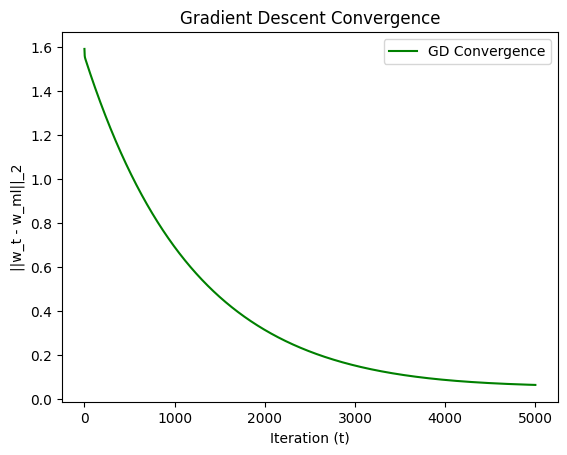

In [13]:
print("\n--- Part (ii): Gradient Descent ---")
# Parameters for GD
learning_rate_gd = 0.01
iterations_gd = 5000

w_gd, gd_norms = gradient_descent(X_train_b, y_train, w_ml, 
                                  learning_rate=learning_rate_gd, 
                                  n_iterations=iterations_gd)

plt.plot(range(iterations_gd), gd_norms, label = 'GD Convergence', c ='g')
plt.xlabel('Iteration (t)')
plt.ylabel('||w_t - w_ml||_2')
plt.legend()
plt.title('Gradient Descent Convergence')
plt.show()

Text(0, 0.5, 'Weight Value')

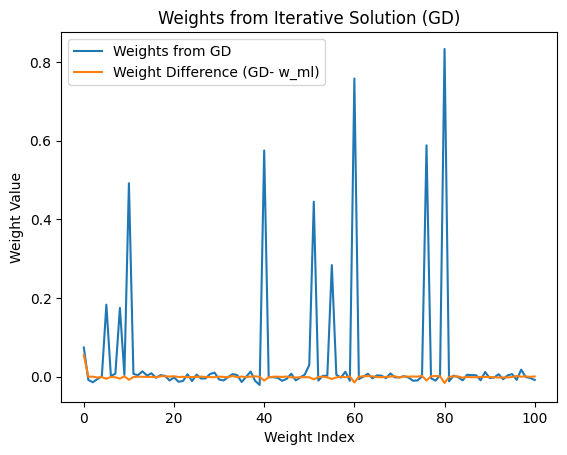

In [14]:
plt.plot(w_gd, label = 'Weights from GD')
plt.plot(w_gd - w_ml, label = 'Weight Difference (GD- w_ml)')
plt.title("Weights from Iterative Solution (GD)")
plt.xlabel("Weight Index")
plt.legend()
plt.ylabel("Weight Value")

In [15]:
# test the MSE for GD 
train_mse_gd = mean_squared_error(X_train_b, y_train, w_gd)
test_mse_gd = mean_squared_error(X_test_b, y_test, w_gd )
print(f"Training MSE (GD): {train_mse_gd}")
print(f"Test MSE (GD): {test_mse_gd}")

Training MSE (GD): 0.03976102837684887
Test MSE (GD): 0.3649096248620074


In [ ]:
# Part 3: SGD
def stochastic_gradient_descent(X, y, w_ml_target, learning_rate= 0.01, n_epochs= 10, batch_size = 32):
    """
    Performs mini-batch stochastic gradient descent.
    Steps:
    - take a random shuffle of data to form a mini batch at each epoch
    - find the gradient of the loss fn on the mini-batch
    - update weights based on this gradient
    
    Returns:
    - w: The final weight vector.
    - norm_differences: A list of ||w_t - w_ml|| norms at each *update step*.
    """
    N, D = X.shape
    
    # 1. Initialize w at zeros
    w = np.zeros((D, 1))
    
    norm_differences = []
    
    # 2. Outer loop for epochs
    for epoch in range(n_epochs):
        
        # 3. --- Shuffle the data ---
        # Create a permutation of indices
        indices = np.random.permutation(N)
        # Reorder X and y based on the shuffled indices
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # 4. Inner loop for mini-batches
        for i in range(0, N, batch_size):
            
            # 5. Get the mini-batch
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            
            # Get the actual batch size (for the last, possibly smaller, batch)
            m = X_batch.shape[0]
            
            # 6. Calculate batch predictions and error
            predictions = X_batch @ w
            error = predictions - y_batch
            
            # 7. Calculate the batch gradient
            gradient = (1 / m) * (X_batch.T @ error)
            
            # 8. Update w
            w = w - learning_rate * gradient
            
            # 9. Store the norm of the difference *after each update*
            norm_diff = np.linalg.norm(w - w_ml_target)
            norm_differences.append(norm_diff)
            
    return w, norm_differences



In [ ]:

print("\n--- Part (iii): Stochastic Gradient Descent ---")
# Parameters for SGD
learning_rate_sgd = 0.01
epochs_sgd = 100
batch_size_sgd = 100
total_updates = int(epochs_sgd * (X_train_b.shape[0] / batch_size_sgd))

w_sgd, sgd_norms = stochastic_gradient_descent(X_train_b, y_train, w_ml,
                                               learning_rate=learning_rate_sgd,
                                               n_epochs=epochs_sgd,
                                               batch_size=batch_size_sgd)



--- Part (iii): Stochastic Gradient Descent ---


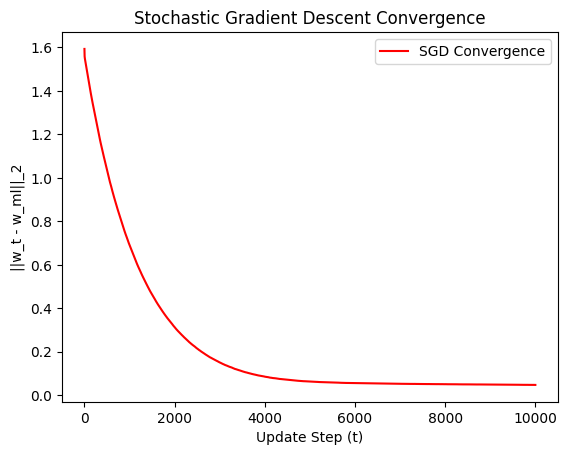

In [ ]:
# SGD convergence plot
plt.plot(range(len(sgd_norms)), sgd_norms, label = 'SGD Convergence', c ='r')
plt.xlabel('Update Step (t)')
plt.ylabel('||w_t - w_ml||_2')
plt.legend()
plt.title('Stochastic Gradient Descent Convergence')
plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_26608\3609296292.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.1)


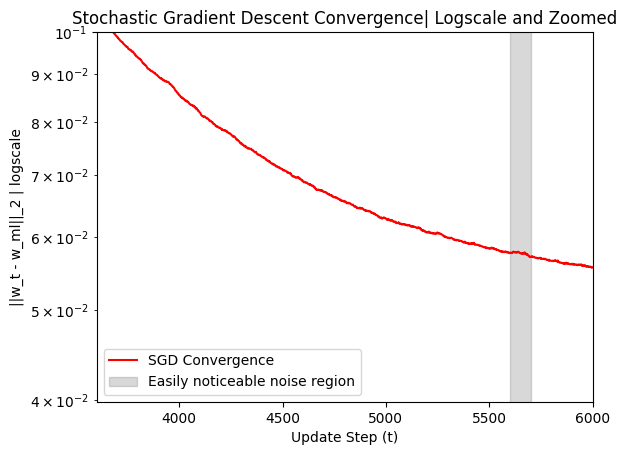

In [ ]:
# visualise noise of SGD convergence
plt.plot(range(len(sgd_norms)), sgd_norms, label = 'SGD Convergence', c ='r')
plt.xlabel('Update Step (t)')
plt.ylabel('||w_t - w_ml||_2 | logscale')
plt.yscale('log')
plt.ylim(0, 0.1)
plt.xlim(3600, 6000)
plt.fill_betweenx( y = [0,1], x1=5600, x2=5700, color='gray', alpha=0.3, label = 'Easily noticeable noise region')
plt.legend()

plt.title('Stochastic Gradient Descent Convergence| Logscale and Zoomed')
plt.show()

Text(0, 0.5, 'Weight Value')

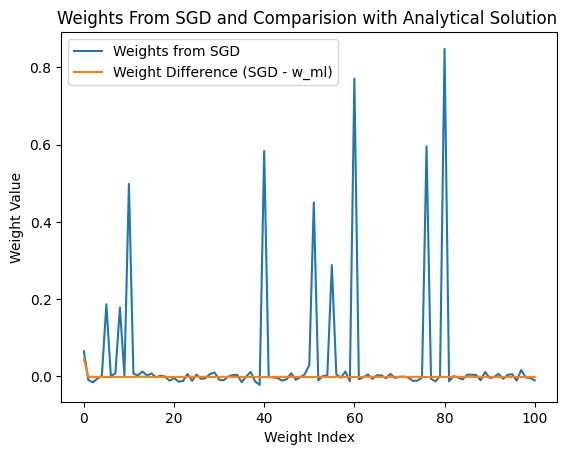

In [20]:
plt.plot(w_sgd, label = 'Weights from SGD')
plt.plot(w_sgd - w_ml, label = 'Weight Difference (SGD - w_ml)')
plt.title("Weights From SGD and Comparision with Analytical Solution ")
plt.legend()
plt.xlabel("Weight Index")
plt.ylabel("Weight Value")

In [21]:
# test MSE for SGD 
train_mse_sgd = mean_squared_error(X_train_b, y_train, w_sgd)
test_mse_sgd = mean_squared_error(X_test_b, y_test, w_sgd)
print(f"Training MSE (SGD): {train_mse_sgd}")
print(f"Test MSE (SGD): {test_mse_sgd}")


Training MSE (SGD): 0.039731022655768
Test MSE (SGD): 0.370983588933495


In [ ]:
def ridge_gradient_descent(X, y, learning_rate, reg_param, n_iterations):
    """
    Performs batch gradient descent for Ridge Regression.
    """
    N, D = X.shape
    w = np.zeros((D, 1))
    
    for t in range(n_iterations):
        predictions = X @ w
        error = predictions - y
        data_gradient = (1 / N) * (X.T @ error)
        
        w_reg = np.copy(w)
        w_reg[0, 0] = 0  # bias term is not penalised
        reg_gradient = 2 * reg_param * w_reg
        
        gradient = data_gradient + reg_gradient
        
        # ---  safety check for explosion ---
        if np.isinf(np.linalg.norm(gradient)):
             print(f"Warning: Gradient exploded with lambda={reg_param} at iter={t}")
             # Return a 'bad' w so MSE is inf
             return np.full_like(w, np.inf)

        w = w - learning_rate * gradient
        
    return w



In [ ]:
print("\n--- Part (iv): Ridge Regression (Corrected) ---")

# --- 1. Cross-Validation Setup ---
split_ratio = 0.8
N_train = X_train_b.shape[0]
split_index = int(N_train * split_ratio)

X_subtrain = X_train_b[:split_index]
y_subtrain = y_train[:split_index]
X_validation = X_train_b[split_index:]
y_validation = y_train[split_index:]

# --- FIX 1: New Lambda search space ---
#  search for smaller values, from 1e-6 to 100 since min lambda was best 
lambda_values = np.logspace(-6, 2, 30)
validation_errors = []

# --- FIX 2: New (smaller) Learning Rate ---
ridge_lr = 0.005 
# Using 500 iterations for CV is fine for speed
cv_iterations = 500 

print(f"Cross-validating over {len(lambda_values)} lambda values with lr={ridge_lr}...")

# --- 2. Run Cross-Validation ---
for lam in lambda_values:
    w_r = ridge_gradient_descent(X_subtrain, y_subtrain,
                                 learning_rate=ridge_lr,
                                 reg_param=lam,
                                 n_iterations=cv_iterations)
    
    val_error = mean_squared_error(X_validation, y_validation, w_r)
    validation_errors.append(val_error)

print("Cross-validation complete.")




--- Part (iv): Ridge Regression (Corrected) ---
Cross-validating over 30 lambda values with lr=0.005...
Cross-validation complete.


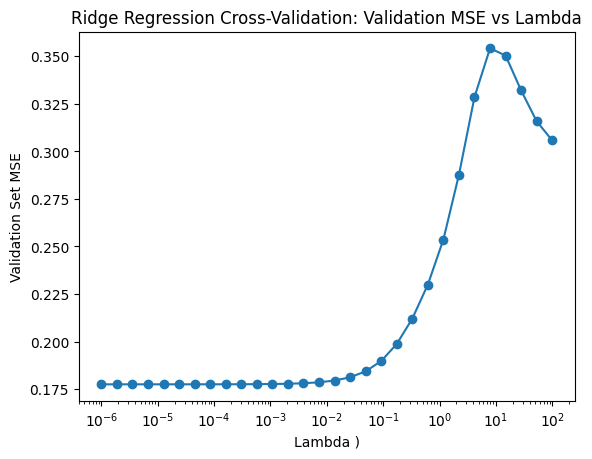

In [24]:
# Plot MSE vs Lambda values
plt.plot(lambda_values, validation_errors, 'o-' )
plt.xscale('log')
plt.xlabel('Lambda )')
plt.ylabel('Validation Set MSE')
plt.title('Ridge Regression Cross-Validation: Validation MSE vs Lambda')
plt.show()

In [ ]:
# --- 3. Find Best Lambda and Train Final Model ---
#  filter out 'inf' errors just in case
valid_errors = np.array(validation_errors)
valid_errors[np.isinf(valid_errors)] = np.nan # Replace inf with nan

if np.all(np.isnan(valid_errors)):
    print("ERROR: All lambda values resulted in an explosion. Try an even smaller learning rate.")
else:
    best_lambda_index = np.nanargmin(valid_errors)
    best_lambda = lambda_values[best_lambda_index]

    print(f"\nBest lambda (A) found: {best_lambda}")
    print(f"Validation MSE at best lambda: {valid_errors[best_lambda_index]}")

    # --- FIX 3: Increase iterations for final model ---
    final_iterations = 2000 
    
    # Train the final w_R model on the *full* training set
    w_r_final = ridge_gradient_descent(X_train_b, y_train,
                                       learning_rate=ridge_lr,
                                       reg_param=best_lambda,
                                       n_iterations=final_iterations)
    
    print(f"Final Ridge model (w_R) trained with {final_iterations} iterations.")

    # --- 4. Compare Test Errors ---
    test_error_ml = mean_squared_error(X_test_b, y_test, w_ml)
    test_error_ridge = mean_squared_error(X_test_b, y_test, w_r_final)

    print("\n--- Test Error Comparison ---")
    print(f"Test MSE for w_ML (Least Squares): {test_error_ml}")
    print(f"Test MSE for w_R (Ridge Regression): {test_error_ridge}")

    if test_error_ridge < test_error_ml:
        print("Observation: The Ridge Regression model (w_R) performed better on the test set.")
    elif test_error_ridge > test_error_ml:
         print("Observation: The standard Least Squares model (w_ML) performed better.")
         print("This can happen if w_ML was already a very good model and not overfitting.")
    else:
        print("Observation: The errors are practically identical.")


Best lambda (A) found: 1e-06
Validation MSE at best lambda: 0.17754210098485795
Final Ridge model (w_R) trained with 2000 iterations.

--- Test Error Comparison ---
Test MSE for w_ML (Least Squares): 0.37075150228804377
Test MSE for w_R (Ridge Regression): 0.25576538814887106
Observation: The Ridge Regression model (w_R) performed better on the test set.


Text(0, 0.5, 'Weight Value')

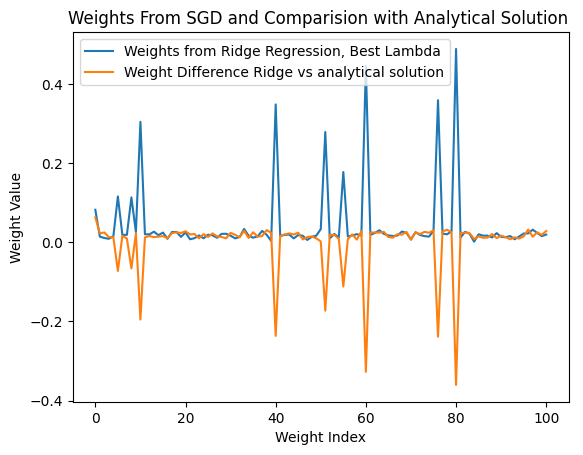

In [ ]:
# weight plot for ridge
plt.plot(w_r_final, label = 'Weights from Ridge Regression, Best Lambda')
plt.plot(w_r_final - w_ml, label = 'Weight Difference Ridge vs analytical solution')
plt.title("Weights From SGD and Comparision with Analytical Solution ")
plt.legend()
plt.xlabel("Weight Index")
plt.ylabel("Weight Value")